# Haar-random states & concentration of measure

Empirically verify **concentration of measure** for Haar-random quantum states.
For a fixed Hamiltonian $H$ on $n$ qubits, if $|\psi\rangle = U|0\rangle$ with $U$
Haar-random, then $\langle\psi|H|\psi\rangle$ concentrates near $\mathrm{Tr}(H)/2^n$
with exponentially small spread (Levy's lemma). States near the ground-state energy
exist but have exponentially small measure, so a random draw essentially never
lands near one — this is the seed of the **barren plateau** problem.

Plan (see `HAAR_SPEC.md`):
1. Build random circuits that approximate Haar-random states at `n = 10`.
2. Define a **global** $H = I - |0\rangle\langle 0|^{\otimes n}$ and a **local**
   $H = \tfrac{1}{n}\sum_i Z_i$; get $\mathrm{Tr}(H)/2^n$ and ground-state energy.
3. Sample $\langle H\rangle$ over `N = 20` random states (`shots = 500`).
4. Compare **Aer simulator vs ibm_fez**, and **global vs local**.
5. Histograms showing the clustering around $\mathrm{Tr}(H)/2^n$.

Develop on Aer first; only the fixed `N=20 / 500 shots` config goes to hardware.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator, random_statevector
from qiskit_aer import AerSimulator
from collections import Counter

# One RNG seeded once, threaded through everything, so a run is reproducible
# and global/local Hamiltonians can be evaluated on the *same* random draws.
rng = np.random.default_rng(1234)

## 1. Random state preparation

A circuit that approximates a Haar-random state: repeat `depth` times a layer of
random single-qubit rotations ($R_x R_y R_z$ with angles $\sim \mathrm{Uniform}(0,2\pi)$)
on every qubit, then a fixed CZ ladder to entangle. Deeper → closer to a 2-design.
`depth` is tunable; we'll check empirically how deep is "deep enough" later.

In [7]:
def create_haar_random_states(num_qubits, depth=5):
    qc = QuantumCircuit(num_qubits)
    for _ in range(depth):
        for qbit in range(num_qubits):
            qc.ry(rng.uniform(0, 2*np.pi), qbit)
            qc.rz(rng.uniform(0, 2*np.pi), qbit)
        for qbit in range(num_qubits-1): 
            qc.cz(qbit, qbit+1) # entangling layer to reach all posisble states

    for qbit in range(num_qubits):
        qc.ry(rng.uniform(0, 2*np.pi), qbit)
        qc.rz(rng.uniform(0, 2*np.pi), qbit)
    return qc

def local_hamiltonian_single_pauli_strings(num_qubits, pauli="Z", coeffs=None):
    """Strings for a local Hamiltonian: a single Pauli on one qubit, I elsewhere.
    n=3, pauli="Z"  ->  ["ZII", "IZI", "IIZ"]
    """
    if coeffs is None:
        coeffs = np.full(num_qubits, 1 / num_qubits) 

    terms = []
    for i in range(num_qubits):
        label = ["I"] * num_qubits
        label[i] = pauli
        terms.append(("".join(label), coeffs[i]))
    return terms

def expectation_value(qc, H):
    return Statevector(qc).expectation_value(H).real

In [8]:
def sample_expectation_values(num_qubits, H, num_samples, depth):
    e_vals = []
    ops_list=[]
    for _ in range(num_samples):
        qc = create_haar_random_states(num_qubits, depth)
        ops_list.append(qc.count_ops())     # one dict per circuit
        e_vals.append(expectation_value(qc, H))
    return np.array(e_vals), ops_list

def aggregate_ops(ops_list):
    """Sum gate counts across all circuits in the job.
    Returns (per_op_totals dict, grand_total int)."""
    totals = Counter()
    for ops in ops_list:
        totals.update(ops)            # adds ry+ry, cz+cz, ... across circuits
    return dict(totals), sum(totals.values())

def per_depth_summary(num_qubits, H, num_samples, depth):
    """Run one config, return its metrics (keep vals for plotting later)."""
    vals, ops_list = sample_expectation_values(num_qubits, H, num_samples, depth)
    per_op, _ = aggregate_ops(ops_list)
    return {
        "depth": depth,
        "mean": vals.mean(),
        "std":  vals.std(),
        "cz":   per_op.get("cz", 0),
        "ry":   per_op.get("ry", 0),
        "rz":   per_op.get("rz", 0),
        "vals": vals,
    }

def print_sweep(rows, haar_std=None):
    print(f"{'depth':>5} {'mean':>9} {'std':>9} {'cz':>7} {'ry':>7} {'rz':>7}")
    for r in rows:
        print(f"{r['depth']:>5} {r['mean']:>9.4f} {r['std']:>9.4f} {r['cz']:>7} {r['ry']:>7} {r['rz']:>7}")
    if haar_std is not None:
        print(f"\ntarget Haar std \u2248 {haar_std:.4f}")


In [9]:
N_QUBITS = 10  # fixed per spec
N_SAMPLES = 20
depths = [1, 3, 5, 10, 15, 20]
H_local = SparsePauliOp.from_list(local_hamiltonian_single_pauli_strings(N_QUBITS, "Z", None))
haar_std = 1 / np.sqrt(N_QUBITS * 2**N_QUBITS)     # ~0.0099 target
rows     = [per_depth_summary(N_QUBITS, H_local, 200, d) for d in depths]
print_sweep(rows, haar_std)


depth      mean       std      cz      ry      rz
    1    0.0280    0.1888    1800    4000    4000
    3   -0.0036    0.1212    5400    8000    8000
    5    0.0043    0.0845    9000   12000   12000
   10    0.0029    0.0523   18000   22000   22000
   15    0.0010    0.0371   27000   32000   32000
   20    0.0012    0.0307   36000   42000   42000

target Haar std ≈ 0.0099


In [ ]:
# we learnt above that we are unable to build a deep enough circuit to create a true haar random state. So lets use qiski inbuilt StateVetcor to draw random haar states

def sample_true_haar_expectation(num_qubits, H, num_samples):
    """Draw EXACT Haar-random states (no circuit, no depth) and measure <psi|H|psi>."""
    d = 2 ** num_qubits
    e_vals = [random_statevector(d, seed=rng).expectation_value(H).real for _ in range(num_samples)]

    return np.array(e_vals)

H_local = SparsePauliOp.from_list(local_hamiltonian_single_pauli_strings(N_QUBITS, "Z", None))
haar_std = 1 / np.sqrt(N_QUBITS * 2**N_QUBITS)  
true_haar_vals = sample_true_haar_expectation(N_QUBITS, H_local, 5000)
print(f"true-Haar mean = {true_haar_vals.mean():+.5f}   (theory: 0)")
print(f"true-Haar std  = {true_haar_vals.std():.5f}    (theory: {haar_std:.5f})")


true-Haar mean = +0.00003   (theory: 0)
true-Haar std  = 0.00985    (theory: 0.00988)


In [ ]:
sim = AerSimulator()

def measure_local_H_shots(state, num_qubits, shots=500):
    qc = QuantumCircuit(num_qubits)
    qc.initialize(state.data, range(num_qubits))
    qc.measure_all()
    counts = sim.run(qc, shots=shots).result().get_counts()
    # per bitstring: (1/n) * sum_i (+1 for '0', -1 for '1'); weight by count

    total=0.0
    for bitstring, freq in counts.items():
        # calc <H>
        z_values = [1-2*int(bit) for bit in bitstring]
        h_local_value = sum(z_values)/num_qubits
        total += h_local_value*freq
    return total/shots

states = [random_statevector(2**N_QUBITS, seed=rng) for _ in range(5000)]
exact  = np.array([s.expectation_value(H_local).real        for s in states])
shots  = np.array([measure_local_H_shots(s, N_QUBITS, 10000)  for s in states])

print(f"exact std (haar_energy_spread)       = {exact.std():.5f}")
print(f"shots std (haar_energy_spread+noise) = {shots.std():.5f}")
shot_noise = np.sqrt(max(shots.var() - exact.var(), 0))
print(f"=> shot-noise alone      ≈ {shot_noise:.5f}   (haar_energy_spread is {exact.std():.5f})")


exact std (signal)       = 0.00985
shots std (signal+noise) = 0.01039
=> shot-noise alone      ≈ 0.00328   (signal is 0.00985)


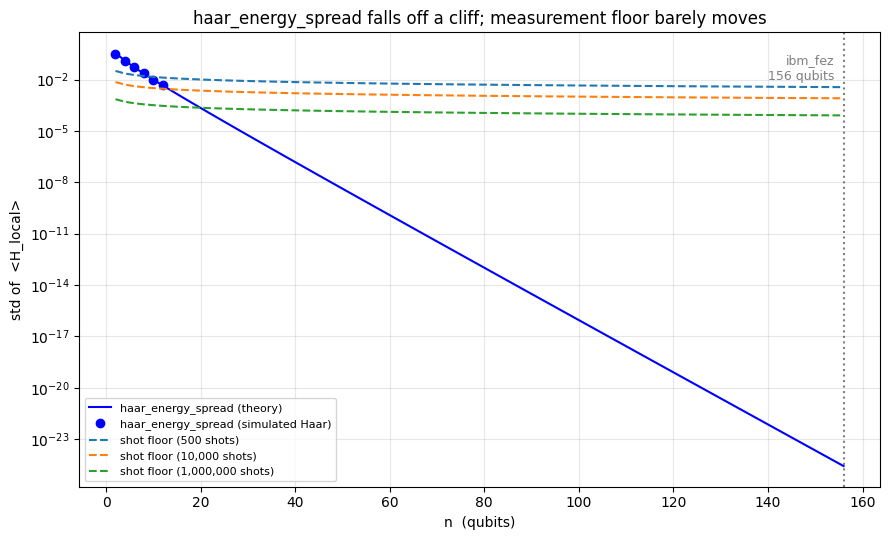

In [17]:
# ---- n-scaling: concentration signal vs shot-noise floor ----

# Chunk 1: x-axis qubit counts and the shot budgets to draw as floors
qubit_counts_full     = np.arange(2, 158, 2)      # [2, 4, ..., 156]  — smooth theory line. IBM_FEZ = 156 so simulating
qubit_counts_measured = [2, 4, 6, 8, 10, 12]      # subset where we also simulate real Haar states
shot_counts           = [500, 10_000, 1_000_000]  # three measurement budgets -> three floor lines

# Chunk 2: the signal, two ways
# THEORY: formula 1/sqrt(n * 2^n) at every qubit count
haar_std_theory = 1.0 / np.sqrt(qubit_counts_full * 2.0**qubit_counts_full)

# MEASURED: actually draw 1000 Haar states at each small n and take their std (confirms theory)
haar_std_measured = []
for n in qubit_counts_measured:
    H = SparsePauliOp.from_list(local_hamiltonian_single_pauli_strings(n, "Z", None))
    e_vals = sample_true_haar_expectation(n, H, 1000)
    haar_std_measured.append(e_vals.std())

# Chunk 3: plot (log y-axis, since values span ~0.1 down to ~1e-25)
plt.figure(figsize=(9, 5.5))

plt.semilogy(qubit_counts_full,     haar_std_theory,   'b-', label='haar_energy_spread (theory)')
plt.semilogy(qubit_counts_measured, haar_std_measured, 'bo', label='haar_energy_spread (simulated Haar)')

for shots in shot_counts:
    floor = 1.0 / np.sqrt(qubit_counts_full * shots)   # smallest std this many shots can resolve
    plt.semilogy(qubit_counts_full, floor, '--', label=f'shot floor ({shots:,} shots)')

plt.axvline(156, color='gray', ls=':')
plt.text(154, 1e-2, 'ibm_fez\n156 qubits', ha='right', color='gray', fontsize=9)

plt.xlabel('n  (qubits)')
plt.ylabel('std of  <H_local>')
plt.title('haar_energy_spread falls off a cliff; measurement floor barely moves')
plt.legend(loc='lower left', fontsize=8)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


> **Note — this is all classical simulation** (no real quantum hardware), done
> with qiskit's `Statevector`. A truly random (Haar) state is made simply: write
> down all of the state's amplitudes as random numbers — each one a random
> complex number drawn from a bell curve (Gaussian) — then rescale them so the
> total probability adds to 1. That points the state in a completely random
> direction, with every possible state equally likely. Because the amplitudes
> are random across all combinations at once, these states are almost always
> highly **entangled** — entanglement is the rule here, not the exception. The
> blue dots come from generating many such states this way and measuring each
> one's energy. (This is only possible because we're simulating: on real
> hardware you can't just *write down* a random state — you'd have to build it
> with gates, which for a random state takes impossibly many.)

### What this experiment is doing, and why

**The question.** If you pick a quantum state completely at random and measure
its energy, what do you get? There's a classic prediction — *concentration of
measure* — that almost every random state gives nearly the **same** energy (the
average), and that they cluster ever more tightly around that average as the
system grows. We want to test that, measure how fast the clustering tightens
with system size, and ask whether a real experiment could ever detect the tiny
leftover variation.

**What we do.** For each system size (number of qubits), we generate many truly
random states, measure each one's energy, and record how much those energies
*spread* around the average. We compute this exactly for small systems, check it
against a predicted formula, then push the formula out to the size of a real
machine (156 qubits).

### Reading the graph

The vertical axis is the **spread** of random-state energies — how much the
energy varies from one random state to the next. Smaller = more tightly clustered.

- **Blue line — the prediction.** A formula for how much the energy should
  spread at each system size. It plunges down: the bigger the system, the more
  every random state piles up at the same average energy. Roughly, the spread
  halves every couple of qubits.

- **Blue dots — the reality check.** At small sizes we didn't trust the formula
  blindly — we actually generated random states and measured their spread.
  *Each dot is the spread (standard deviation) of the energies of 1000 random
  Haar states at that qubit count — not their average (the average is ≈ 0; the
  spread is what we care about).* The dots land right on the line, so the
  prediction is confirmed. (We can only afford to compute the dots for small
  systems, which is why they stop early while the line carries on.)

- **Dashed lines — what a real measurement can see.** Any real measurement has a
  limited budget and can only detect a spread bigger than some floor. Where the
  blue line falls **below** a dashed line, the spread is too small to ever
  measure — it's lost in the noise of measuring.

**The punchline.** By the size of a real machine, the blue line has dropped far
below every dashed line. So random states on a large machine are useless for
finding low-energy states: they all give essentially the average energy, and the
differences that would matter are far too small to ever detect.